# Xie swap-station device data

This notebook lists the 271 released devices with their labels, loads all devices, and plots the cell voltages of one device. It makes no diagnosis.

## 1. Released units

This step lists what `systems('xie')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('xie')
display(released)

,unit,device_label,fault_codes
0,0022234cc5964eae8c383cc9032cd51f,2,2
1,002239cfb0584149a6814aacf1a7b557,2,2
2,009180d7550b4f44bd8feedb6d1bec86,3,3
3,00dc55c44bcf46bd817a8cb6d77bceb5,5,5
4,011f10a7b8ba47aea358f0201038d869,5,5
...,...,...,...
266,fb86dd67337f49f9bfc260cfda3b2c0b,5,5
267,fc3787e09628425fb939714ff8670326,5,5
268,fc8ba414a31f4f1abf78b6c5d72ba9c8,5,5
269,fe77a876a44a4cbc9d9d75a808e8cf58,5,5


Each row is one device file with its device label from the released records table.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
released = systems('xie')
frame = load('xie', unit=list(released['unit']))
print(frame.shape)
display(frame.head())

(20780, 28)


,totalCurrent,batCoreTempCount,batCoreVoltage1,batCoreVoltage2,batCoreVoltage3,batCoreVoltage4,batCoreVoltage5,batCoreVoltage6,batCoreVoltage7,batCoreVoltage8,...,batCoreVoltage17,batCoreVoltage18,batCoreVoltage19,batCoreVoltage20,batCoreTemp1,batCoreTemp2,batCoreTemp3,batCoreTemp4,batCoreTemp5,unit
dateTime,,,,,,,,,,,,,,,,,,,,,
2024-10-03 21:54:08.543000+00:00,0.00,5.0,3294.0,3289.0,3290.0,3294.0,3292.0,3288.0,3287.0,3289.0,...,3292.0,3293.0,3294.0,3293.0,30.0,31.0,32.0,32.0,31.0,0022234cc5964eae8c383cc9032cd51f
2024-10-04 04:54:08.565000+00:00,7.65,5.0,3389.0,3388.0,3384.0,3391.0,3389.0,3386.0,3387.0,3385.0,...,3389.0,3394.0,3389.0,3394.0,32.0,34.0,35.0,35.0,34.0,0022234cc5964eae8c383cc9032cd51f
2024-10-04 11:54:09.099000+00:00,0.00,5.0,3311.0,3292.0,3311.0,3322.0,3299.0,3294.0,3295.0,3303.0,...,3301.0,3304.0,3309.0,3298.0,36.0,37.0,39.0,38.0,37.0,0022234cc5964eae8c383cc9032cd51f
2024-10-04 18:54:09.170000+00:00,0.00,5.0,3329.0,3299.0,3325.0,3332.0,3314.0,3304.0,3306.0,3319.0,...,3317.0,3320.0,3325.0,3310.0,33.0,35.0,36.0,36.0,34.0,0022234cc5964eae8c383cc9032cd51f
2024-10-04 21:54:08.794000+00:00,0.00,5.0,3326.0,3298.0,3324.0,3332.0,3311.0,3301.0,3302.0,3316.0,...,3314.0,3317.0,3322.0,3307.0,29.0,30.0,31.0,31.0,30.0,0022234cc5964eae8c383cc9032cd51f


All 271 devices together are 20,780 rows. Rows are hours apart, and each device has 16 to 20 cell-voltage columns in mV.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['totalCurrent', 'batCoreVoltage1', 'batCoreVoltage16', 'batCoreTemp1']].describe().T)

,count,mean,std,min,25%,50%,75%,max
totalCurrent,20780.0,-9.714149,154.909596,-4053.0,0.00,0.0,0.0,1265.0
batCoreVoltage1,20780.0,2757.684745,1227.621942,0.0,3261.75,3294.0,3329.0,3645.0
batCoreVoltage16,20780.0,2756.162175,1226.802063,0.0,3257.00,3290.0,3328.0,3650.0
batCoreTemp1,20780.0,20.595043,10.416217,0.0,19.00,22.0,27.0,54.0


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

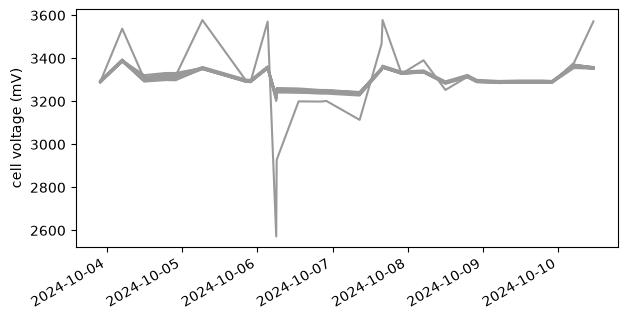

In [4]:
one = frame[frame['unit'] == frame['unit'].iloc[0]]
cells = [c for c in one.columns if c.startswith('batCoreVoltage') and one[c].gt(0).any()]
ax = one[cells].plot(figsize=(7, 3.5), color='0.6', legend=False)
ax.set_xlabel('')
ax.set_ylabel('cell voltage (mV)')
plt.show()

Most cells of this device move together, and one cell departs from the group several times. That kind of departure is what the paper's fault screening looks for.